In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import snowflake.connector
from cryptography.hazmat.primitives import serialization
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

load_dotenv('../.env')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

with open("../keys/rsa_key.p8", "rb") as key_file:
    private_key = serialization.load_pem_private_key(key_file.read(), password=None)

conn = snowflake.connector.connect(
    account=os.getenv('SNOWFLAKE_ACCOUNT'),
    user=os.getenv('SNOWFLAKE_USER'),
    private_key=private_key,
    warehouse=os.getenv('SNOWFLAKE_WAREHOUSE'),
    database=os.getenv('SNOWFLAKE_DATABASE'),
    schema=os.getenv('SNOWFLAKE_SCHEMA'),
    role='ACCOUNTADMIN'
)

cursor = conn.cursor()
cursor.execute("USE DATABASE OLIST_DB")
cursor.execute("USE SCHEMA RAW_MARTS")

print("Connected successfully")

Connected successfully


In [3]:
df = pd.read_sql("SELECT * FROM MART_CUSTOMER_CHURN", conn)
df.columns = df.columns.str.lower()
print(f"Shape: {df.shape}")
print(f"\nChurn rate: {df['is_churned'].mean():.1%}")
print(f"\nChurn status breakdown:")
print(df['churn_status'].value_counts())

Shape: (98207, 20)

Churn rate: 81.6%

Churn status breakdown:
churn_status
Churned - Long Ago    59998
Churned - Recent      20151
At Risk               12554
Active                 5504
Name: count, dtype: int64


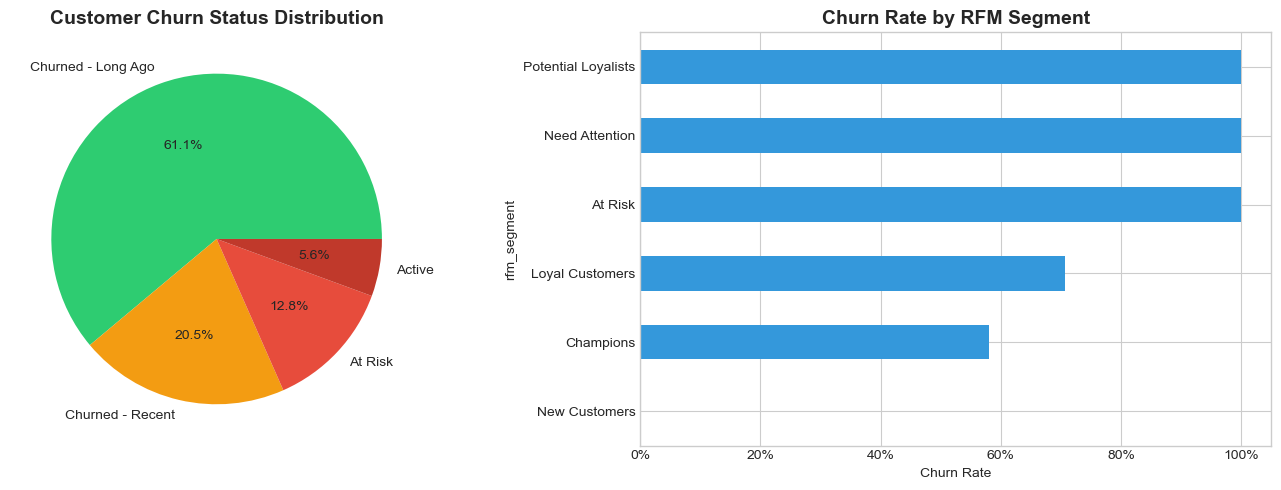

Saved churn_distribution.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn status breakdown
churn_counts = df['churn_status'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#c0392b']
axes[0].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%', colors=colors)
axes[0].set_title('Customer Churn Status Distribution', fontsize=14, fontweight='bold')

# Churn by RFM segment
segment_churn = df.groupby('rfm_segment')['is_churned'].mean().sort_values(ascending=True)
segment_churn.plot(kind='barh', ax=axes[1], color='#3498db')
axes[1].set_title('Churn Rate by RFM Segment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Churn Rate')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.savefig('../data/processed/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved churn_distribution.png")

In [5]:
metrics = ['recency_days', 'frequency', 'monetary', 'avg_order_value', 'avg_review_score', 'avg_delivery_days']

summary = df.groupby('churn_status')[metrics].mean().round(2)
print("Average metrics by churn status:")
print(summary.to_string())

Average metrics by churn status:
                    recency_days  frequency  monetary  avg_order_value  avg_review_score  avg_delivery_days
churn_status                                                                                               
Active                     20.41       1.00    155.19           155.17              4.31               7.40
At Risk                    59.41       1.00    165.15           164.87              4.28               8.95
Churned - Long Ago        341.63       1.01    158.82           157.78              4.07              13.71
Churned - Recent          137.02       1.00    166.28           166.01              4.09              12.51


In [6]:
# Split into high-value vs low-value based on median monetary spend
median_spend = df['monetary'].median()
df['customer_segment'] = np.where(df['monetary'] >= median_spend, 'High Value', 'Low Value')

high_value = df[df['customer_segment'] == 'High Value']['is_churned']
low_value = df[df['customer_segment'] == 'Low Value']['is_churned']

# Chi-square test
from scipy.stats import chi2_contingency
contingency = pd.crosstab(df['customer_segment'], df['is_churned'])
chi2, p_value, dof, expected = chi2_contingency(contingency)

print("=" * 50)
print("A/B TEST: High Value vs Low Value Customers")
print("=" * 50)
print(f"High Value churn rate: {high_value.mean():.1%}")
print(f"Low Value churn rate:  {low_value.mean():.1%}")
print(f"\nChi-square statistic: {chi2:.2f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")
print(f"\nResult: {'SIGNIFICANT (p < 0.05) — high-value customers churn at different rates' if p_value < 0.05 else 'NOT significant'}")

A/B TEST: High Value vs Low Value Customers
High Value churn rate: 81.4%
Low Value churn rate:  81.9%

Chi-square statistic: 3.95
P-value: 0.046807
Degrees of freedom: 1

Result: SIGNIFICANT (p < 0.05) — high-value customers churn at different rates


In [7]:
df_reviews = df[df['avg_review_score'].notna()].copy()
high_review = df_reviews[df_reviews['avg_review_score'] >= 4]['is_churned']
low_review = df_reviews[df_reviews['avg_review_score'] < 4]['is_churned']

contingency2 = pd.crosstab(
    df_reviews['avg_review_score'] >= 4,
    df_reviews['is_churned']
)
chi2_r, p_value_r, _, _ = chi2_contingency(contingency2)

print("=" * 50)
print("A/B TEST: High Review Score vs Low Review Score")
print("=" * 50)
print(f"High review (4+) churn rate: {high_review.mean():.1%}")
print(f"Low review (<4) churn rate:  {low_review.mean():.1%}")
print(f"\nP-value: {p_value_r:.6f}")
print(f"Result: {'SIGNIFICANT' if p_value_r < 0.05 else 'NOT significant'}")

A/B TEST: High Review Score vs Low Review Score
High review (4+) churn rate: 80.4%
Low review (<4) churn rate:  85.7%

P-value: 0.000000
Result: SIGNIFICANT


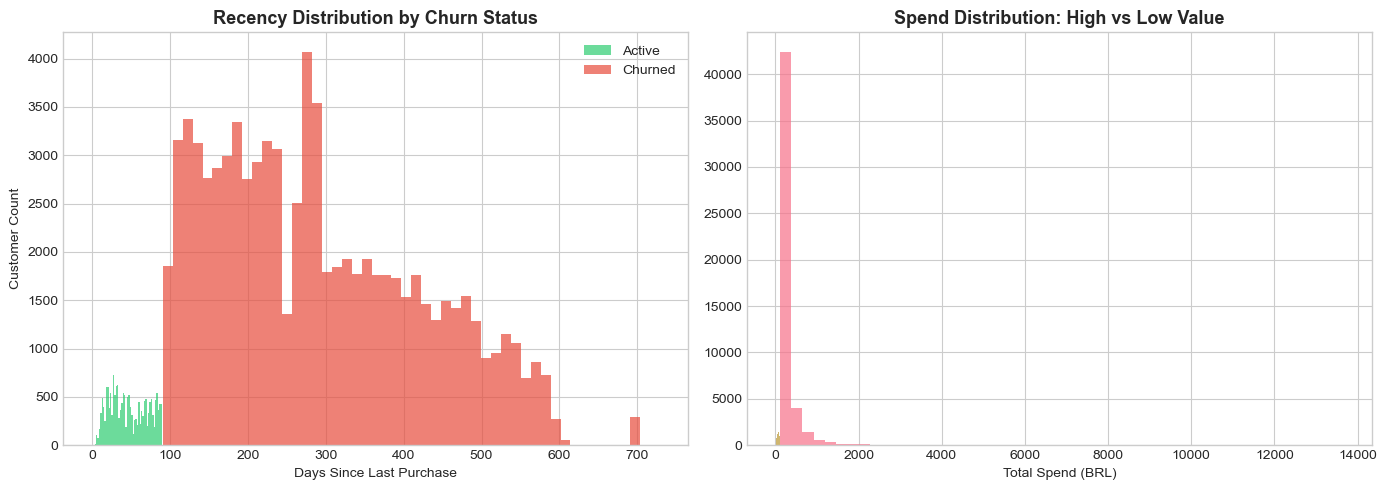

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[df['is_churned']==0]['recency_days'], bins=50, alpha=0.7, label='Active', color='#2ecc71')
axes[0].hist(df[df['is_churned']==1]['recency_days'], bins=50, alpha=0.7, label='Churned', color='#e74c3c')
axes[0].set_xlabel('Days Since Last Purchase')
axes[0].set_ylabel('Customer Count')
axes[0].set_title('Recency Distribution by Churn Status', fontsize=13, fontweight='bold')
axes[0].legend()

# Monetary by segment
df.groupby('customer_segment')['monetary'].hist(bins=50, alpha=0.7, ax=axes[1])
axes[1].set_xlabel('Total Spend (BRL)')
axes[1].set_title('Spend Distribution: High vs Low Value', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/recency_spend_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
state_churn = df.groupby('customer_state').agg(
    churn_rate=('is_churned', 'mean'),
    customer_count=('customer_unique_id', 'count'),
    avg_spend=('monetary', 'mean')
).reset_index().sort_values('churn_rate', ascending=False)

print("Top 10 states by churn rate:")
print(state_churn.head(10).to_string(index=False))

# Save for Tableau
state_churn.to_csv('../data/processed/state_churn.csv', index=False)
df.to_csv('../data/processed/customer_churn_features.csv', index=False)
print("\nSaved state_churn.csv and customer_churn_features.csv")

Top 10 states by churn rate:
customer_state  churn_rate  customer_count  avg_spend
            AC    0.876543              81 242.835802
            RO    0.865854             246 233.429959
            AL    0.858881             411 234.871265
            MA    0.853261             736 205.198505
            AP    0.852941              68 239.158824
            CE    0.846561            1323 208.128057
            PA    0.845201             969 225.093695
            MT    0.840355             902 206.607228
            RS    0.839764            5417 162.862677
            PI    0.838776             490 220.095286

Saved state_churn.csv and customer_churn_features.csv
